In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import shap

c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv('Titanic_train.csv')

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [12]:
most_common_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common_port)

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [14]:
df['Cabin_Level'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')

In [15]:
df.drop('Cabin' , axis =1 , inplace = True)

In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_Level
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,U
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,U
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,U


In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Cabin_Level    0
dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

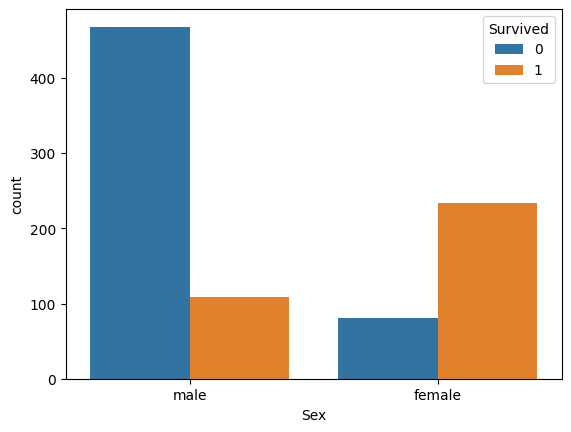

In [18]:
sns.countplot(x=df['Sex'],hue=df['Survived'])

C:\Users\LOQ\AppData\Local\Temp\ipykernel_32332\384713476.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass',y='Survived',data=df,palette='viridis')


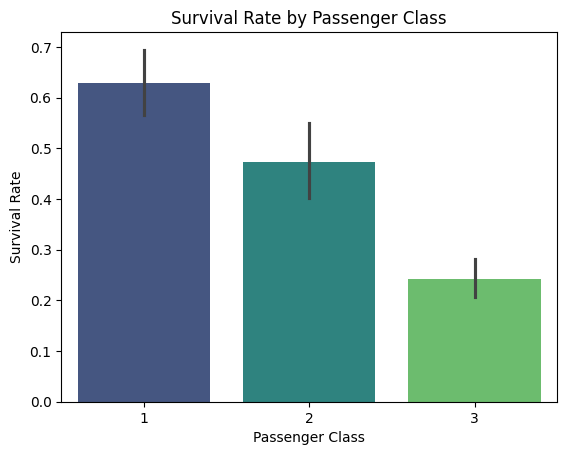

In [19]:
sns.barplot(x='Pclass',y='Survived',data=df,palette='viridis')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class')
plt.show()

In [20]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

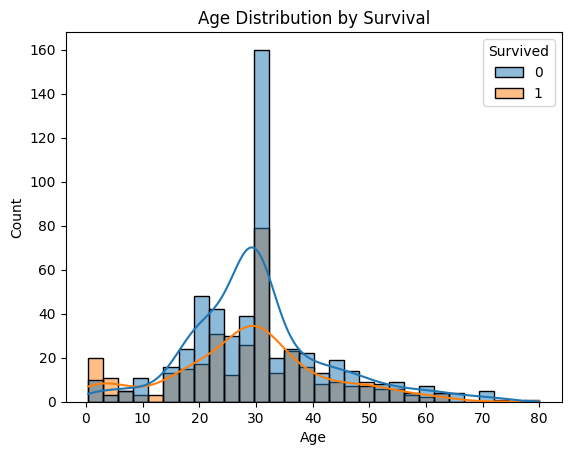

In [21]:
sns.histplot(data=df,x='Age',hue='Survived',kde= True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [22]:
df['Sex'] = df['Sex'].map({'female':0 , 'male':1})

In [23]:
print(df['Sex'].head())

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64


In [24]:
df = pd.get_dummies(df,columns=['Embarked'])

In [25]:
df = df.astype({col:int for col in df.columns if 'Embarked_' in col})

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,U,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,U,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,U,0,0,1


In [27]:
cabin_levels_order ={"A":7,"B":6,"C":5,"D":4,"E":3,"F":2,"G":1,"U":0}

In [28]:
df['Cabin_Level'] = df['Cabin_Level'].map(cabin_levels_order)

In [29]:
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1

In [30]:
def classify_family(size):
  if size == 1:
    return 'Alone'
  elif size>=2 and size <=4:
    return 'Small'
  else:
    return 'Large'

In [31]:
df['FamilyClassification'] = df['FamilySize'].apply(classify_family)

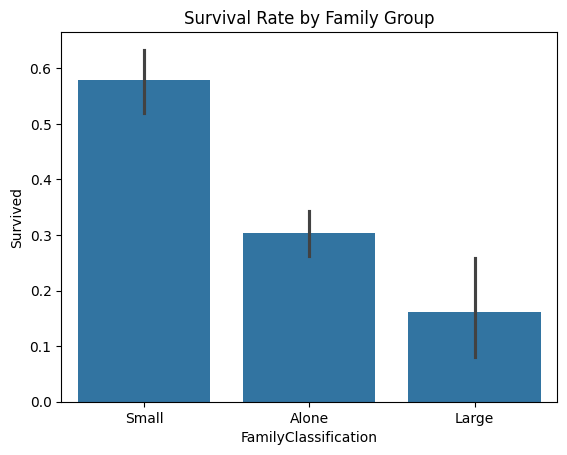

In [32]:
sns.barplot(x='FamilyClassification', y='Survived', data=df)
plt.title('Survival Rate by Family Group')
plt.show()

In [33]:
Family_Group_Mapping ={
    'Large': 0,
    'Alone':1,
    'Small':2
}
df['FamilyClassification_Encoded'] = df['FamilyClassification'].map(Family_Group_Mapping)

In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S,FamilySize,FamilyClassification,FamilyClassification_Encoded
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0.0,0,0,1,2,Small,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,5.0,1,0,0,2,Small,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0.0,0,0,1,1,Alone,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,5.0,0,0,1,2,Small,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0.0,0,0,1,1,Alone,1


In [35]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\LOQ\AppData\Local\Temp\ipykernel_32332\172848211.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [36]:
def Clean_Titles(title):
  if title in ['Mlle' , 'Ms'] :
    return 'Miss'
  elif title == 'Mme':
    return 'Mrs'
  elif title in  ['Capt', 'Col', 'Major', 'Dr', 'Rev', 'Jonkheer', 'Sir', 'Lady', 'Countess','Don']:
    return 'Special_Titles'
  else:
    return title

df['Title_Cleaned'] = df['Title'].apply(Clean_Titles)

In [37]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S,FamilySize,FamilyClassification,FamilyClassification_Encoded,Title,Title_Cleaned
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,0.0,0,0,1,2,Small,2,Mr,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,5.0,1,0,0,2,Small,2,Mrs,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,0.0,0,0,1,1,Alone,1,Miss,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,5.0,0,0,1,2,Small,2,Mrs,Mrs
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,0.0,0,0,1,1,Alone,1,Mr,Mr
5,6,0,3,"Moran, Mr. James",1,29.699118,0,0,330877,8.4583,0.0,0,1,0,1,Alone,1,Mr,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.000000,0,0,17463,51.8625,3.0,0,0,1,1,Alone,1,Mr,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.000000,3,1,349909,21.0750,0.0,0,0,1,5,Large,0,Master,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.000000,0,2,347742,11.1333,0.0,0,0,1,3,Small,2,Mrs,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.000000,1,0,237736,30.0708,0.0,1,0,0,2,Small,2,Mrs,Mrs


C:\Users\LOQ\AppData\Local\Temp\ipykernel_32332\2057627091.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Title_Cleaned', y='Survived', data=df, palette='viridis', ci=None)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_32332\2057627091.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title_Cleaned', y='Survived', data=df, palette='viridis', ci=None)


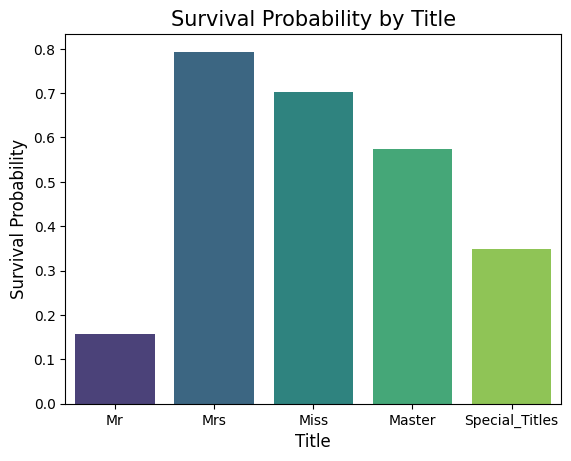

In [38]:
sns.barplot(x='Title_Cleaned', y='Survived', data=df, palette='viridis', ci=None)

plt.title('Survival Probability by Title', fontsize=15)
plt.xlabel('Title', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.show()

In [39]:
Title_Mapping = {
    'Mr' : 0,
    'Special_Titles':1,
    'Master': 2,
    'Miss':3,
    'Mrs' :4,

}
df['Title_Encoded'] = df['Title_Cleaned'].map(Title_Mapping)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S,FamilySize,FamilyClassification,FamilyClassification_Encoded,Title,Title_Cleaned,Title_Encoded
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0.0,0,0,1,2,Small,2,Mr,Mr,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,5.0,1,0,0,2,Small,2,Mrs,Mrs,4
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0.0,0,0,1,1,Alone,1,Miss,Miss,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,5.0,0,0,1,2,Small,2,Mrs,Mrs,4
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0.0,0,0,1,1,Alone,1,Mr,Mr,0


In [40]:
ClassificationAgeNumbers =[0 , 12 , 18 , 60 , 100]
CategoriesNames = ['Child' , 'Teenager' , 'Adult' , 'Elderly']
df['AgeGroup'] = pd.cut(df['Age'] , bins= ClassificationAgeNumbers , labels= CategoriesNames)

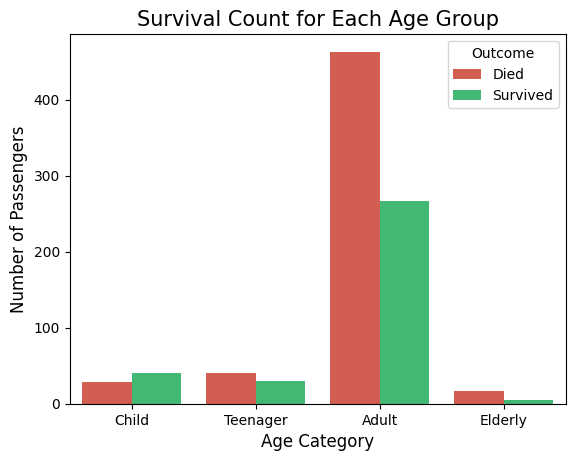

In [41]:
sns.countplot(x='AgeGroup', hue='Survived', data=df, palette=['#E74C3C', '#2ECC71'])

plt.title('Survival Count for Each Age Group', fontsize=15)
plt.xlabel('Age Category', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(title='Outcome', labels=['Died', 'Survived'])

plt.show()

In [42]:
AgeMapping = { 'Child' : 3, 'Teenager': 2 ,'Elderly' : 1, 'Adult': 0}
df['AgeGroup_Encoding'] = df['AgeGroup'].map(AgeMapping)

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_Q,Embarked_S,FamilySize,FamilyClassification,FamilyClassification_Encoded,Title,Title_Cleaned,Title_Encoded,AgeGroup,AgeGroup_Encoding
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,...,0,1,2,Small,2,Mr,Mr,0,Adult,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,0,0,2,Small,2,Mrs,Mrs,4,Adult,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,...,0,1,1,Alone,1,Miss,Miss,3,Adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,0,1,2,Small,2,Mrs,Mrs,4,Adult,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,...,0,1,1,Alone,1,Mr,Mr,0,Adult,0


In [44]:
df.drop(['Name','PassengerId','Title','AgeGroup','Title_Cleaned','FamilyClassification','Ticket'],axis=1,inplace=True)

In [45]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S,FamilySize,FamilyClassification_Encoded,Title_Encoded,AgeGroup_Encoding
0,0,3,1,22.000000,1,0,7.2500,0.0,0,0,1,2,2,0,0
1,1,1,0,38.000000,1,0,71.2833,5.0,1,0,0,2,2,4,0
2,1,3,0,26.000000,0,0,7.9250,0.0,0,0,1,1,1,3,0
3,1,1,0,35.000000,1,0,53.1000,5.0,0,0,1,2,2,4,0
4,0,3,1,35.000000,0,0,8.0500,0.0,0,0,1,1,1,0,0
5,0,3,1,29.699118,0,0,8.4583,0.0,0,1,0,1,1,0,0
6,0,1,1,54.000000,0,0,51.8625,3.0,0,0,1,1,1,0,0
7,0,3,1,2.000000,3,1,21.0750,0.0,0,0,1,5,0,2,3
8,1,3,0,27.000000,0,2,11.1333,0.0,0,0,1,3,2,4,0
9,1,2,0,14.000000,1,0,30.0708,0.0,1,0,0,2,2,4,2


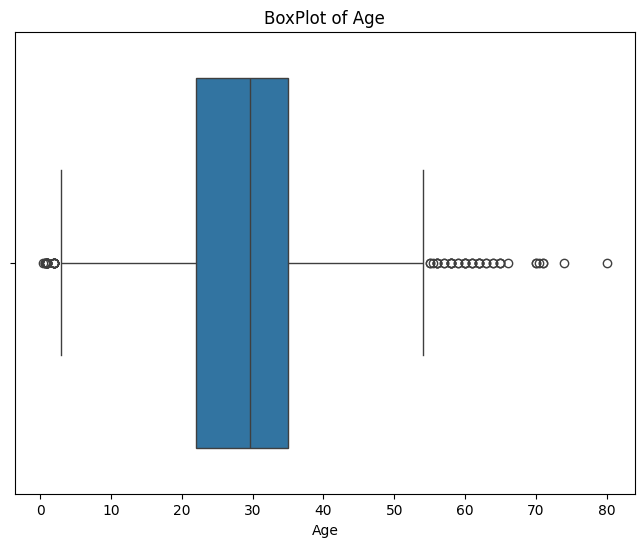

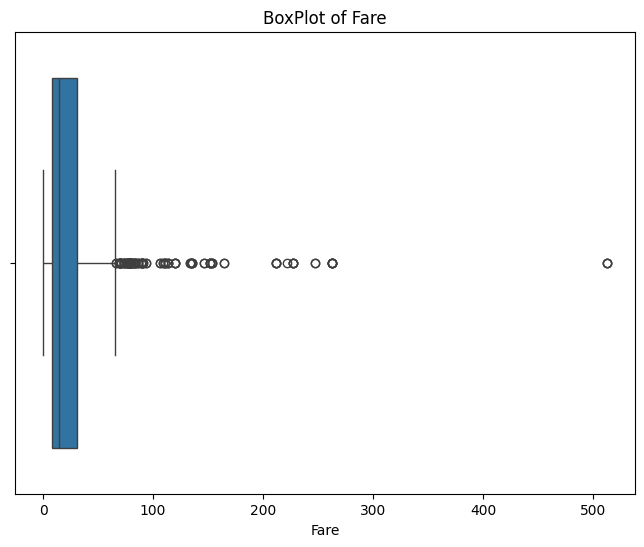

In [46]:
numeric_columns=['Age','Fare']
for col in numeric_columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'BoxPlot of {col}')
    plt.show()

In [47]:
for col in numeric_columns:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[col]=df[col].clip(lower=lower_bound,upper=upper_bound)


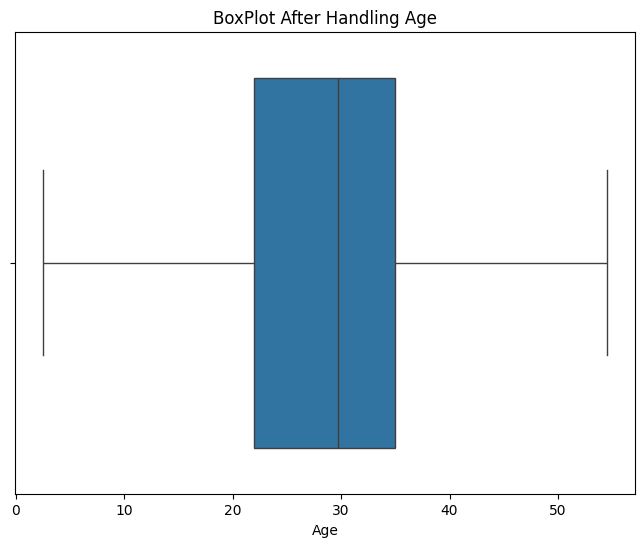

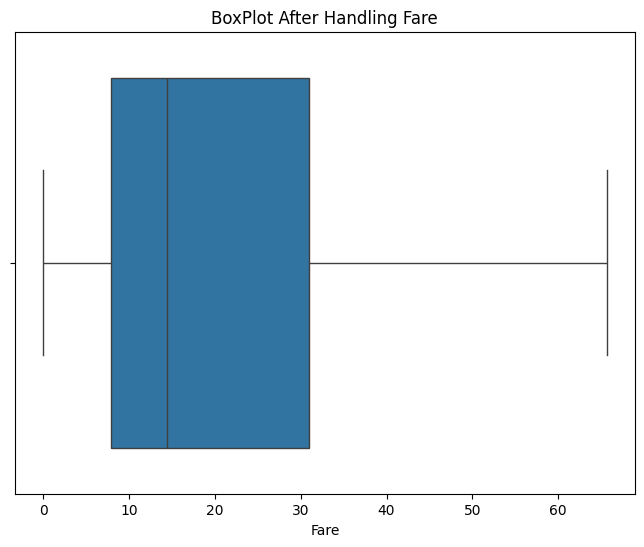

In [48]:
for col in numeric_columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'BoxPlot After Handling {col}')
    plt.show()

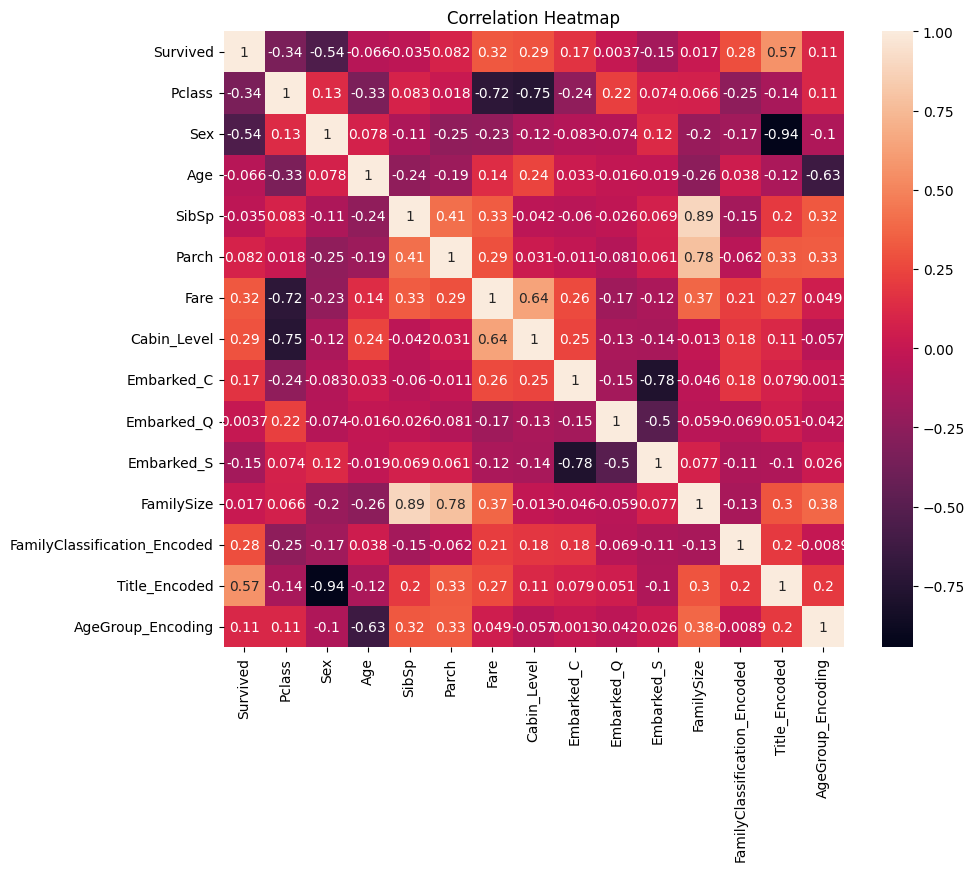

In [49]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [50]:
scal_columns=['Age','Fare']
for col in scal_columns:
    df[col]=(df[col]-df[col].min())/(df[col].max()-df[col].min())

In [51]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S,FamilySize,FamilyClassification_Encoded,Title_Encoded,AgeGroup_Encoding
0,0,3,1,0.375000,1,0,0.110460,0.0,0,0,1,2,2,0,0
1,1,1,0,0.682692,1,0,1.000000,5.0,1,0,0,2,2,4,0
2,1,3,0,0.451923,0,0,0.120745,0.0,0,0,1,1,1,3,0
3,1,1,0,0.625000,1,0,0.809027,5.0,0,0,1,2,2,4,0
4,0,3,1,0.625000,0,0,0.122649,0.0,0,0,1,1,1,0,0


In [52]:
test_set = pd.read_csv('Titanic_test.csv')

In [53]:
def apply_on_test_set(df):
    df = df.copy()

    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
    most_common_port = df['Embarked'].mode()[0]
    df['Embarked'] = df['Embarked'].fillna(most_common_port)
    df['Cabin_Level'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
    cabin_levels_order = {"A":7, "B":6, "C":5, "D":4, "E":3, "F":2, "G":1, "U":0}
    df['Cabin_Level'] = df['Cabin_Level'].map(cabin_levels_order)
    df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
    df = pd.get_dummies(df, columns=['Embarked'])
    df = df.astype({col: int for col in df.columns if 'Embarked_' in col})
    df['FamilySize'] = df['Parch'] + df['SibSp'] + 1
    def classify_family(size):
        if size == 1: return 'Alone'
        elif 2 <= size <= 4: return 'Small'
        else: return 'Large'
    df['FamilyClassification'] = df['FamilySize'].apply(classify_family)
    df['FamilyClassification_Encoded'] = df['FamilyClassification'].map({'Large': 0, 'Alone': 1, 'Small': 2})
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    def clean_titles(title):
        if title in ['Mlle', 'Ms']: return 'Miss'
        elif title == 'Mme': return 'Mrs'
        elif title in ['Capt', 'Col', 'Major', 'Dr', 'Rev', 'Jonkheer', 'Sir', 'Lady', 'Countess', 'Don']: return 'Special_Titles'
        else: return title
    df['Title_Cleaned'] = df['Title'].apply(clean_titles)
    df['Title_Encoded'] = df['Title_Cleaned'].map({'Mr': 0, 'Special_Titles': 1, 'Master': 2, 'Miss': 3, 'Mrs': 4})
    df['Title_Encoded'] = df['Title_Encoded'].fillna(0)
    classification_age = [0, 12, 18, 60, 100]
    categories_names = ['Child', 'Teenager', 'Adult', 'Elderly']
    df['AgeGroup'] = pd.cut(df['Age'], bins=classification_age, labels=categories_names)
    df['AgeGroup_Encoding'] = df['AgeGroup'].map({'Adult': 0, 'Elderly': 1, 'Teenager': 2, 'Child': 3})
    numeric_columns = ['Age', 'Fare']
    for col in numeric_columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Title', 'Title_Cleaned',
                       'FamilyClassification', 'AgeGroup', 'SibSp', 'Parch']
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

    return df

In [54]:
apply_on_test_set(test_set)

,Pclass,Sex,Age,Fare,Cabin_Level,Embarked_C,Embarked_Q,Embarked_S,FamilySize,FamilyClassification_Encoded,Title_Encoded,AgeGroup_Encoding
0,3,1,34.50000,7.8292,0,0,1,0,1,1,0.0,0
1,3,0,47.00000,7.0000,0,0,0,1,2,2,4.0,0
2,2,1,54.87500,9.6875,0,0,1,0,1,1,0.0,1
3,3,1,27.00000,8.6625,0,0,0,1,1,1,0.0,0
4,3,0,22.00000,12.2875,0,0,0,1,3,2,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,1,30.27259,8.0500,0,0,0,1,1,1,0.0,0
414,1,0,39.00000,66.9063,5,1,0,0,1,1,0.0,0
415,3,1,38.50000,7.2500,0,0,0,1,1,1,0.0,0
416,3,1,30.27259,8.0500,0,0,0,1,1,1,0.0,0


# **SVM**

Best Hyperparameters :  {'C': 10, 'gamma': 0.01}
Cross-Val Accuracy    :  0.8230079779375554
Accuracy  :  0.8539325842696629
[[87 11]
 [15 65]]


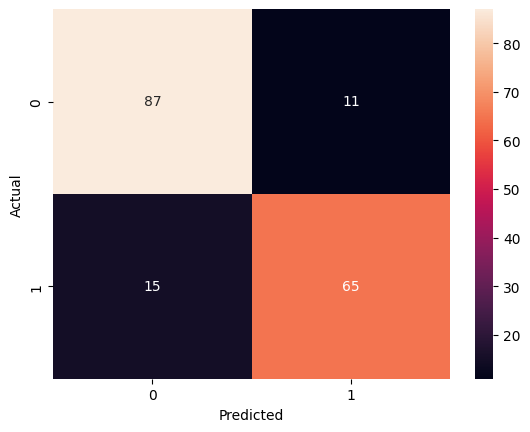

              precision    recall  f1-score   support

           0       0.85      0.89      0.87        98
           1       0.86      0.81      0.83        80

    accuracy                           0.85       178
   macro avg       0.85      0.85      0.85       178
weighted avg       0.85      0.85      0.85       178



In [55]:
df = df.dropna()
x = df.drop(columns="Survived")
y = df["Survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(x_train_scaled, y_train)
best_svm = grid_search.best_estimator_
print("Best Hyperparameters : ", grid_search.best_params_)
print("Cross-Val Accuracy    : ", grid_search.best_score_)

val_accuracy = accuracy_score(y_test, best_svm.predict(x_test_scaled))
print("Accuracy  : ", val_accuracy)

###### Tarek Mohammed & Seif Yasser ######
cm_svm = confusion_matrix(y_test, best_svm.predict(x_test_scaled))
print(cm_svm)
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
report = classification_report(y_test, best_svm.predict(x_test_scaled))
print(report)

In [56]:
test_set = pd.read_csv('Titanic_test.csv')
passenger_id = test_set["PassengerId"]
test_set = apply_on_test_set(test_set)

test_set = test_set.drop(columns=['SibSp', 'Parch'], errors='ignore')
x_train = x_train.drop(columns=['SibSp', 'Parch'], errors='ignore')
x_test = x_test.drop(columns=['SibSp', 'Parch'], errors='ignore')

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
test_set_scaled = scaler.transform(test_set)

grid_search.fit(x_train_scaled, y_train)
best_svm = grid_search.best_estimator_

final_predictions = best_svm.predict(test_set_scaled)

df_testing = pd.DataFrame({
    'PassengerId': passenger_id,
    'Survived': final_predictions
})

df_testing.to_csv('Final_Titanic_Predictions_SVM.csv', index=False)

# **LogisticRegression Part**

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 0 to 890
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Survived                      890 non-null    int64   
 1   Pclass                        890 non-null    int64   
 2   Sex                           890 non-null    int64   
 3   Age                           890 non-null    float64 
 4   SibSp                         890 non-null    int64   
 5   Parch                         890 non-null    int64   
 6   Fare                          890 non-null    float64 
 7   Cabin_Level                   890 non-null    float64 
 8   Embarked_C                    890 non-null    int64   
 9   Embarked_Q                    890 non-null    int64   
 10  Embarked_S                    890 non-null    int64   
 11  FamilySize                    890 non-null    int64   
 12  FamilyClassification_Encoded  890 non-null    int64   


c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


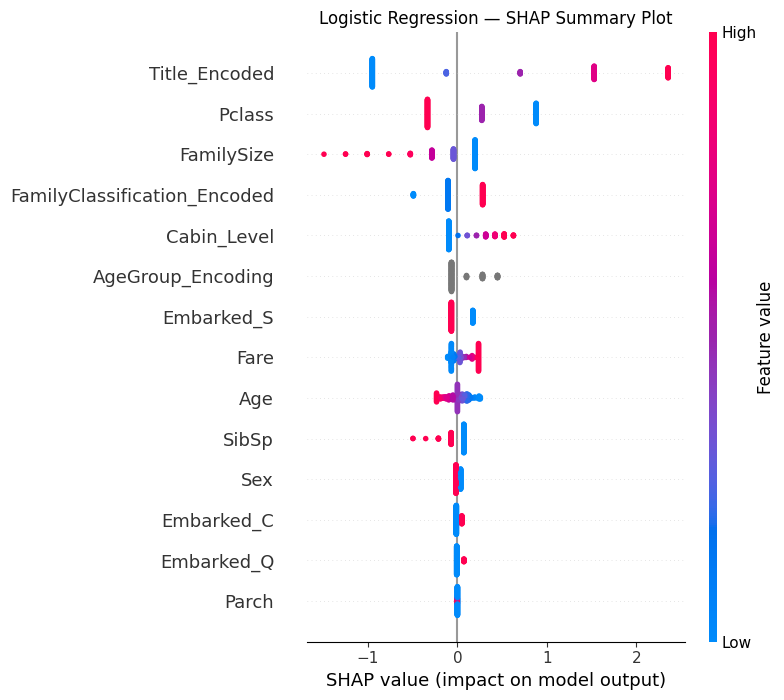

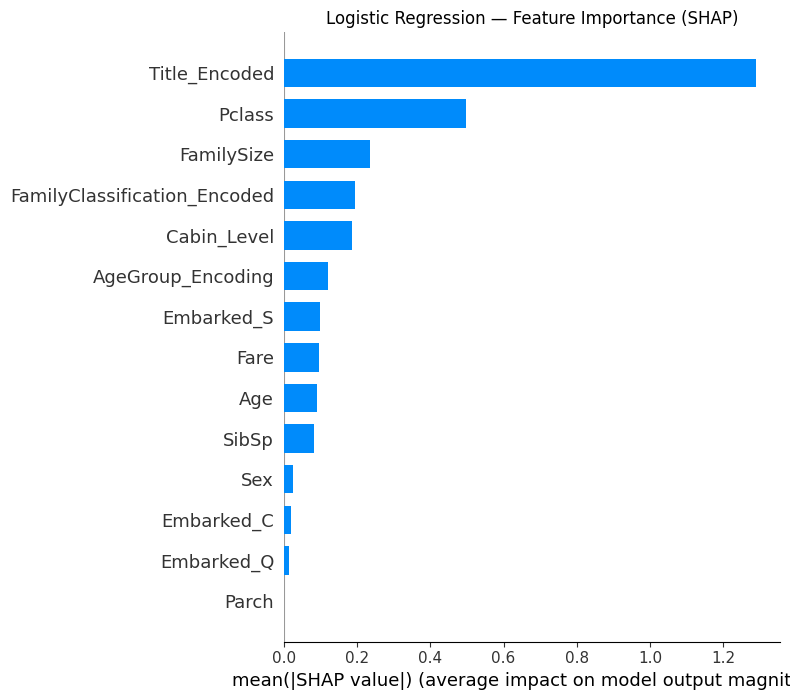

[[81 17]
 [12 68]]


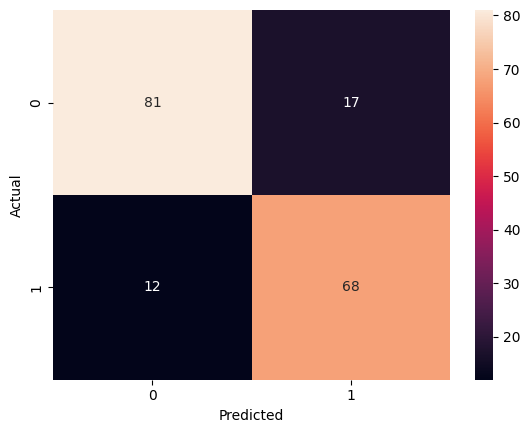

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        98
           1       0.80      0.85      0.82        80

    accuracy                           0.84       178
   macro avg       0.84      0.84      0.84       178
weighted avg       0.84      0.84      0.84       178



In [57]:
####### Adam Atito #######

df.info()
df = df.dropna()
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

x = df.drop(columns="Survived")
y = df["Survived"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

log = LogisticRegression(max_iter=1000, random_state=42)

param_distribution = {'C' : np.logspace(-3, 3, 20), 'penalty' : ['l1', 'l2'], 'solver' : ['liblinear', 'saga']}

random_search = RandomizedSearchCV(estimator=log, param_distributions=param_distribution, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)  #=> n_jobs for speed processing
random_search.fit(x_train, y_train)

print("Best Hyperparameter after tunning them : ", random_search.best_params_)
print("Cross-Val Accuracy : ", random_search.best_score_)
## for test set ##
best_log_model = random_search.best_estimator_
y_pred = best_log_model.predict(x_test)
final_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy for test set : ", final_accuracy)

###### Tarek Mohammed & Seif Yasser ######
# ============================================================
#  SHAP

explainer_lr = shap.LinearExplainer(
    best_log_model, x_train,
    feature_perturbation="interventional"
)
shap_values_lr = explainer_lr.shap_values(x_test)

# dot Plot
plt.figure()
shap.summary_plot(shap_values_lr, x_test, plot_type="dot", show=False)
plt.title("Logistic Regression — SHAP Summary Plot")
plt.tight_layout()
plt.savefig("shap_lr_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# Bar Plot
plt.figure()
shap.summary_plot(shap_values_lr, x_test, plot_type="bar", show=False)
plt.title("Logistic Regression — Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_lr_bar.png", dpi=150, bbox_inches='tight')
plt.show()


cm_lr = confusion_matrix(y_test, y_pred)
print(cm_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


report = classification_report(y_test,y_pred)
print(report)

In [58]:
test_set = pd.read_csv('Titanic_test.csv')
passenger_id = test_set["PassengerId"]
test_set = apply_on_test_set(test_set)
test_set = test_set.drop(columns=['SibSp', 'Parch'], errors='ignore')
x_train = x_train.drop(columns=['SibSp', 'Parch'], errors='ignore')
x_test = x_test.drop(columns=['SibSp', 'Parch'], errors='ignore')
random_search.fit(x_train, y_train)
best_log_model = random_search.best_estimator_
final_predictions = best_log_model.predict(test_set)
df_testing = pd.DataFrame({
    'PassengerId': passenger_id,
    'Survived': final_predictions
})

df_testing.to_csv('Final_Titanic_Predictions.csv', index=False) ## this file for testing unseen data (score on kaggle)

c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


# **Decision tree**

Best Hyperparameter after tunning them :  {'max_leaf_nodes': 16, 'max_depth': 6}
Cross-Val Accuracy :  0.8159952723333005
Accuracy for test set :  0.8258426966292135
[[88 10]
 [21 59]]


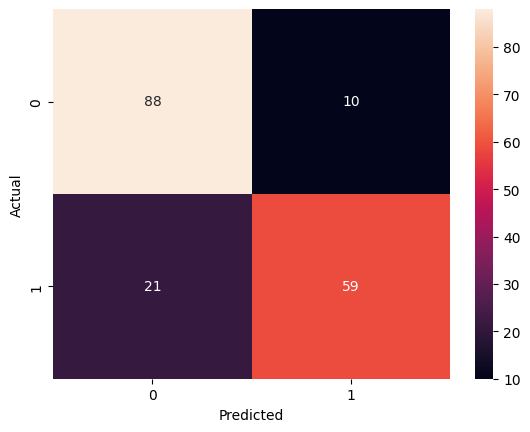

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        98
           1       0.86      0.74      0.79        80

    accuracy                           0.83       178
   macro avg       0.83      0.82      0.82       178
weighted avg       0.83      0.83      0.82       178



In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV

param_distribution = {
    'max_depth': [2, 4, 6, 8, 10, 12, 16],
    'max_leaf_nodes': [2, 4, 6, 8, 16, 32],
}

tree_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)

random_search = RandomizedSearchCV(
    estimator = tree_model,
    param_distributions = param_distribution,
    n_iter = 20,
    cv = 5,
    scoring = 'accuracy',
    random_state = 42,
    n_jobs = -1
)

random_search.fit(x_train, y_train)

best_params = random_search.best_params_
print("Best Hyperparameter after tunning them : ", random_search.best_params_)
print("Cross-Val Accuracy : ", random_search.best_score_)

best_tree_model = random_search.best_estimator_
y_pred = best_tree_model.predict(x_test)
final_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy for test set : ", final_accuracy)

x_train_tree = x_train.copy()
test_set = test_set.reindex(columns=x_train_tree.columns, fill_value=0)

final_predictions = best_tree_model.predict(test_set)
df_testing = pd.DataFrame({
    'PassengerId': passenger_id,
    'Survived': final_predictions
})

df_testing.to_csv('Final_Titanic_Predictions.csv', index = False) ## this file for testing unseen data (score on kaggle)

cm_Decision = confusion_matrix(y_test,y_pred)
print(cm_Decision)
sns.heatmap(cm_Decision, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

report = classification_report(y_test,y_pred)
print(report)

# **GUI**

In [ ]:
#!pip install gradio

import gradio as gr
import pandas as pd
import numpy as np

def predict_survival(pclass, name, sex, age, sibsp, parch, fare, cabin, embarked):
    input_df = pd.DataFrame({
        'PassengerId': [9999],
        'Pclass': [pclass],
        'Name': [name],
        'Sex': [sex],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Ticket': ['DummyTicket'], #Don't Care
        'Fare': [fare],
        'Cabin': [cabin if cabin else np.nan],
        'Embarked': [embarked]
    })
    processed_data = apply_on_test_set(input_df)
    processed_data = processed_data.drop(columns=['SibSp', 'Parch'], errors='ignore')
    processed_data = processed_data.reindex(columns=x_train.columns, fill_value=0)
    prediction = best_log_model.predict(processed_data)[0] #training with logistic regression

    if prediction == 1:
        return "Survived"
    else:
        return "Did Not Survive"
interface = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Radio([1, 2, 3], label="درجة التذكرة (Pclass)"),
        gr.Textbox(label="اسم الراكب (يفضل مع اللقب زي Mr, Miss)", placeholder="مثال: Braund, Mr. Owen Harris"),
        gr.Radio(["male", "female"], label="النوع (Sex)"),
        gr.Slider(minimum=1, maximum=100, value=25, step=1, label="العمر (Age)"),
        gr.Number(value=0, label="عدد الإخوة/الزوج (SibSp)"),
        gr.Number(value=0, label="عدد الآباء/الأبناء (Parch)"),
        gr.Number(value=15.0, label="سعر التذكرة (Fare)"),
        gr.Textbox(label="رقم الكابينة (Cabin) - اختياري", placeholder="مثال: C85"),
        gr.Dropdown(["S", "C", "Q"], label="ميناء الركوب (Embarked)")
    ],
    outputs=gr.Textbox(label="توقع الموديل", text_align="center"),
    title=" TITANIC - MODEL ",
    
    description="أدخل بيانات أي راكب لاختبار الموديل ومعرفة احتمالية نجاته.",
    theme="default"
)
interface.launch(debug=True)

c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
